## Problem 1

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw

In [2]:
albums_df = pd.read_csv("Top_10_Albums_By_Year.csv")
anime_df = pd.read_csv("Anime.csv")
algo_df = pd.read_csv("algorithm_trials.csv")

In [3]:
#cleaning data
algo_df['Algorithm'] = algo_df['Algorithm'].str.lower()
albums_df['Genre'] = albums_df['Genre'].str.lower()
albums_df["Worldwide Sales (Est.)"] = albums_df["Worldwide Sales (Est.)"].str.replace(",", "").astype(float)
anime_df["Type"] = anime_df["Type"].str.strip()

#### Anime DF

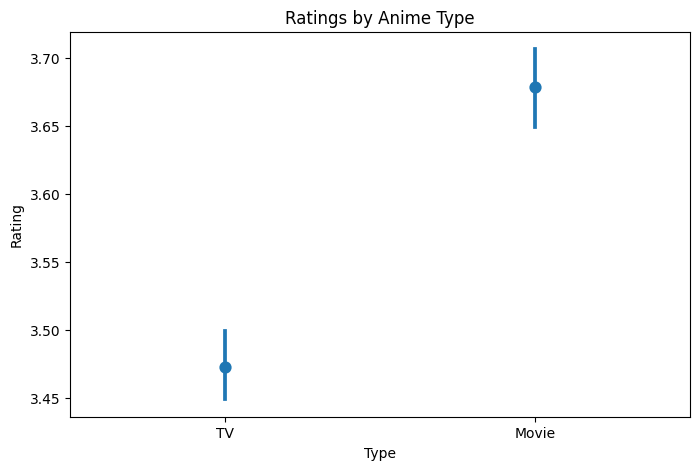

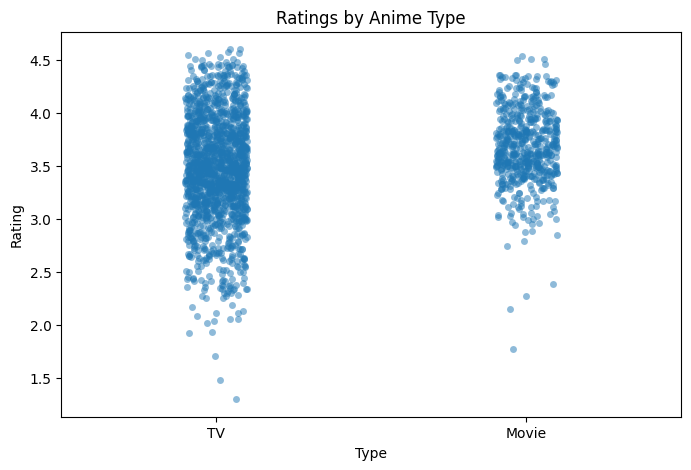

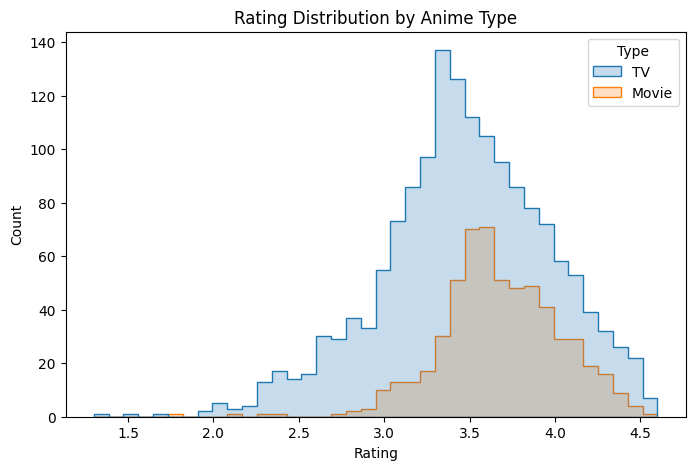

In [4]:
anime_df = anime_df[(anime_df["Release_year"] >= 2015)]
anime_df = anime_df[(anime_df["Type"].isin(["TV","Movie"]))]

"""
#Debug this!
for i in range(len(anime_df)):
    if anime_df["Type"][i] == "TV":
        if anime_df["Episodes"][i] >= 25.0:
            anime_df.drop[i]
""" 

# Error Bar
plt.figure(figsize=(8,5))
sns.pointplot(data=anime_df, x="Type", y="Rating", linestyle="none")
plt.title("Ratings by Anime Type")
plt.show()

# Barcode
plt.figure(figsize=(8,5))
sns.stripplot(data=anime_df, x="Type", y="Rating", alpha=0.5)
plt.title("Ratings by Anime Type")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(data=anime_df, x="Rating", hue="Type", element="step",)
plt.title("Rating Distribution by Anime Type")
plt.show()


#### Algorithm DF

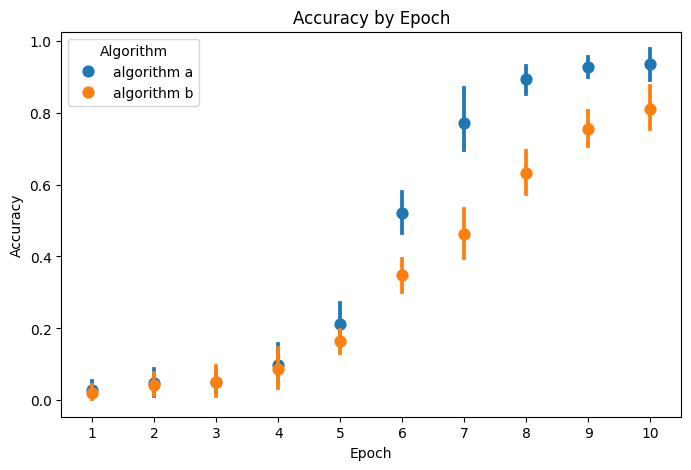

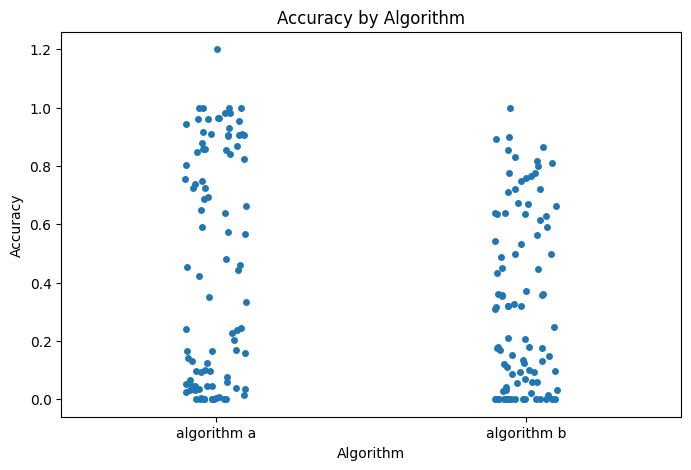

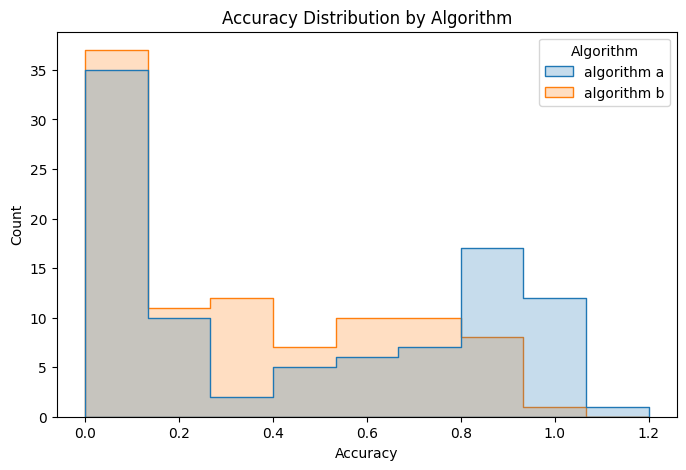

In [5]:
# Error Bar Plot
plt.figure(figsize=(8,5))
sns.pointplot(data=algo_df, x="Epoch", y="Accuracy", hue = "Algorithm", linestyle="none")
plt.title("Accuracy by Epoch")
plt.show()

# Barcode
plt.figure(figsize=(8,5))
sns.stripplot(data=algo_df, x="Algorithm", y="Accuracy")
plt.title("Accuracy by Algorithm")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(data=algo_df, x="Accuracy", hue="Algorithm", element="step")
plt.title("Accuracy Distribution by Algorithm")
plt.show()


#### Albums DF

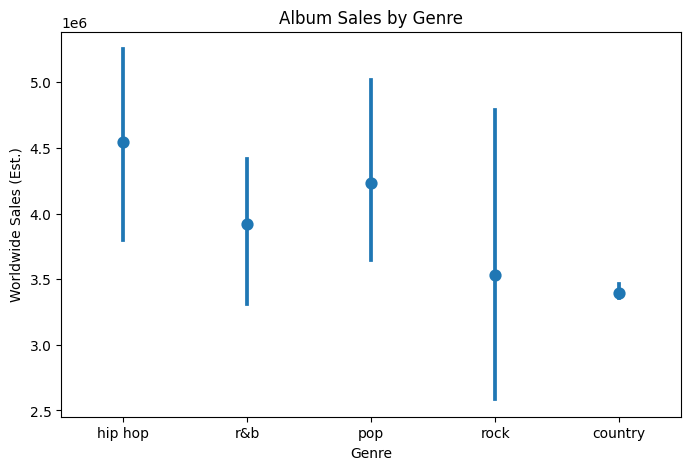

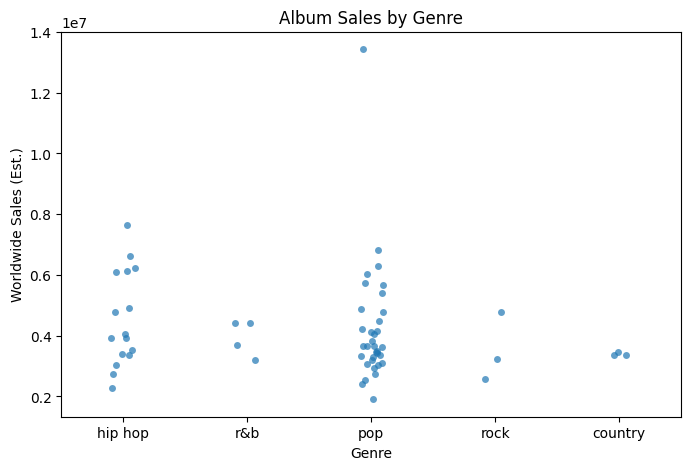

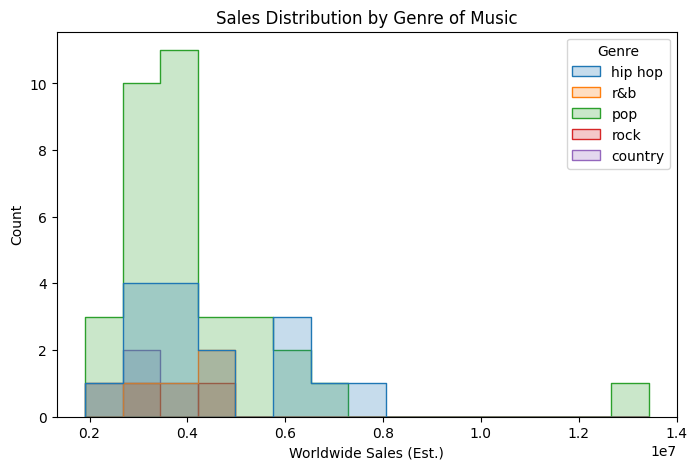

In [6]:
#Filter from 2015 on
albums_df = albums_df[albums_df["Year"] > 2015]

# Error Bar Plot
plt.figure(figsize=(8,5))
sns.pointplot(data=albums_df, x="Genre", y="Worldwide Sales (Est.)", linestyle="none")
plt.title("Album Sales by Genre")
plt.show()

# Barcode
plt.figure(figsize=(8,5))
sns.stripplot(data=albums_df, x="Genre", y="Worldwide Sales (Est.)", alpha=0.7)
plt.title("Album Sales by Genre")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(data=albums_df, x="Worldwide Sales (Est.)", hue="Genre", element="step")
plt.title("Sales Distribution by Genre of Music")
plt.show()

## Problem 2

#### Helper Functions

In [7]:
#Helper functions

def fit_normal(x):
    mu = np.mean(x)
    sigma = np.std(x, ddof=1)
    return mu, sigma

def fit_uniform(x):
    a = np.min(x)
    b = np.max(x)
    return a, b

def fit_exponential(x):
    lam = 1.0 / np.mean(x)
    return lam

def fit_powerlaw(x):
    fit = powerlaw.Fit(x, verbose=False)
    alpha = fit.power_law.alpha
    xmin = fit.power_law.xmin
    return alpha, xmin

#### Uniform Distribution

In [8]:
#For uniform distrubtion I am going to use the "live births in Ohio" for 2024 and 2023
birth_death = pd.read_csv("VSRR_-_State_and_National_Provisional_Counts_for_Live_Births__Deaths__and_Infant_Deaths.csv")
ohio_birth_death = birth_death[(birth_death["State"] == "OHIO")]
ohio_birth_full = ohio_birth_death[(ohio_birth_death["Indicator"] == "Number of Live Births")]
ohio_birth = ohio_birth_full["Data Value"]

print(len(ohio_birth))

18


In [9]:
#Normal Data
mu_b, sigma_b = fit_normal(ohio_birth)

#Uniform Data
a_b, b_b = fit_uniform(ohio_birth)

#Exponential
lambda_b = fit_exponential(ohio_birth)

#Power Law
alpha_b, xmin_b = fit_powerlaw(ohio_birth)

print(f"Normal: mu={mu_b:.2f}, sigma={sigma_b:.2f}")
print(f"Uniform: a={a_b:.3f}, b={b_b:.3f}")
print(f"Exponential: lambda={lambda_b:.6f}")
print(f"Power law: alpha={alpha_b:.3f}, x_min={xmin_b:.3f}")

Normal: mu=10505.94, sigma=400.38
Uniform: a=9675.000, b=11169.000
Exponential: lambda=0.000095
Power law: alpha=52.168, x_min=10647.000


#### Normal Distribution

In [10]:
#The weight-height distrubution -- I'm going to use height

wh_df = pd.read_csv("weight-height.csv")
height_df = wh_df['Height']
print(len(height_df))

10000


In [11]:
#Normal Data
mu_h, sigma_h = fit_normal(height_df)

#Uniform Data
a_h, b_h = fit_uniform(height_df)

#Exponential
lambda_h = fit_exponential(height_df)

#Power Law
alpha_h, xmin_h = fit_powerlaw(height_df)

print(f"Normal: mu={mu_h:.2f}, sigma={sigma_h:.2f}")
print(f"Uniform: a={a_h:.3f}, b={b_h:.3f}")
print(f"Exponential: lambda={lambda_h:.6f}")
print(f"Power law: alpha={alpha_h:.3f}, x_min={xmin_h:.3f}")

Normal: mu=66.37, sigma=3.85
Uniform: a=54.263, b=78.999
Exponential: lambda=0.015068
Power law: alpha=64.806, x_min=73.487


#### Exponential Distribution

In [12]:
customers = pd.read_csv("customer_arrival_time.csv")

total_minutes = customers['min'].sum() + customers['sec'].sum()/60 + customers['cent'].sum()/100/60
interarrivals = customers['min'] + customers['sec']/60 + customers['cent']/100/60
print(len(interarrivals))

74


In [13]:
#Normal Data
mu_ia, sigma_ia = fit_normal(interarrivals)

#Uniform Data
a_ia, b_ia = fit_uniform(interarrivals)

#Exponential
lambda_ia = fit_exponential(interarrivals)

#Power Law
alpha_ia, xmin_ia = fit_powerlaw(interarrivals)

print(f"Normal: mu={mu_ia:.2f}, sigma={sigma_ia:.2f}")
print(f"Uniform: a={a_ia:.3f}, b={b_ia:.3f}")
print(f"Exponential: lambda={lambda_ia:.6f}")
print(f"Power law: alpha={alpha_ia:.3f}, x_min={xmin_ia:.3f}")

Normal: mu=0.79, sigma=0.92
Uniform: a=0.017, b=5.519
Exponential: lambda=1.259503
Power law: alpha=3.373, x_min=1.238


#### Power Law

In [14]:
# The frequency of occurrence of unique words in the novel Moby Dick by Herman Melville
moby_dick = np.loadtxt("https://aaronclauset.github.io/powerlaws/data/words.txt", dtype=int)
num_MD = len(moby_dick)
print(num_MD)

18855


In [15]:
#Normal Data
mu_MD, sigma_MD = fit_normal(moby_dick)

#Uniform Data
a_MD, b_MD = fit_uniform(moby_dick)

#Exponential
lambda_MD = fit_exponential(moby_dick)

#Power Law
alpha_MD, xmin_MD = fit_powerlaw(moby_dick)

print(f"Normal: mu={mu_MD:.2f}, sigma={sigma_MD:.2f}")
print(f"Uniform: a={a_MD:.3f}, b={b_MD:.3f}")
print(f"Exponential: lambda={lambda_MD:.6f}")
print(f"Power law: alpha={alpha_MD:.3f}, x_min={xmin_MD:.3f}")

Normal: mu=11.14, sigma=148.33
Uniform: a=1.000, b=14086.000
Exponential: lambda=0.089788
Power law: alpha=2.023, x_min=6.000


#### Part C: Synthetic

In [16]:
def compare_distributions(real_data, synthetic_data, model_name, dataset_name):
    plt.figure(figsize=(8, 4))
    plt.hist(real_data, bins=100, alpha=0.5, label="Real Data", density=True)
    plt.hist(synthetic_data, bins=100, alpha=0.5, label=f"Synthetic {model_name}", density=True)
    plt.title(f"{dataset_name}: Real vs Synthetic ({model_name})")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

def compare_dist_misbehaved(real_data, synthetic_data, model_name, dataset_name, xlim):
    plt.figure(figsize=(8, 4))
    plt.hist(real_data, bins=100, alpha=0.5, label="Real Data", density=True)
    plt.hist(synthetic_data, bins=100, alpha=0.5, label=f"Synthetic {model_name}", density=True)
    plt.title(f"{dataset_name}: Real vs Synthetic ({model_name})")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.xlim(0,xlim)
    plt.legend()
    plt.show()

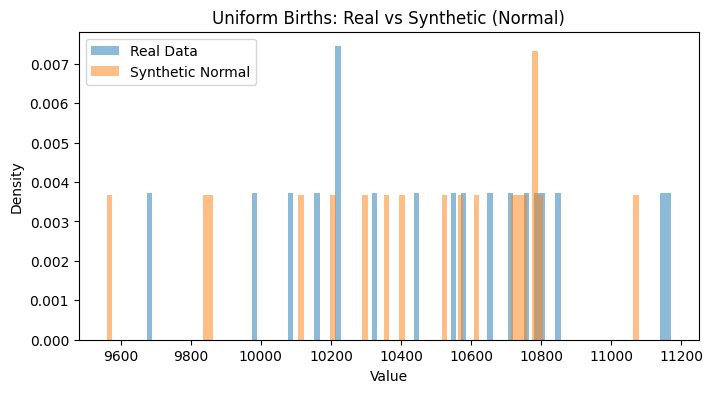

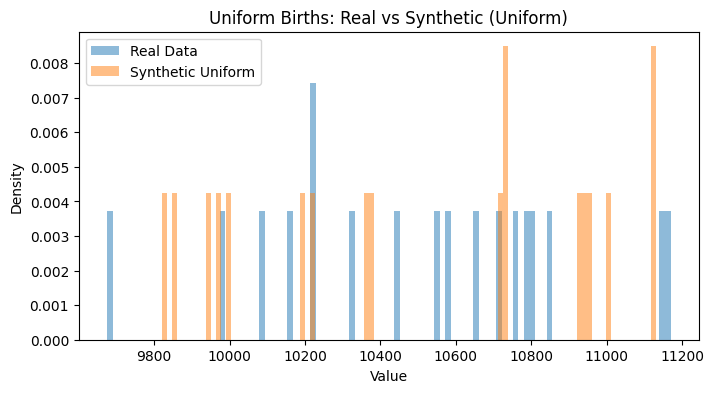

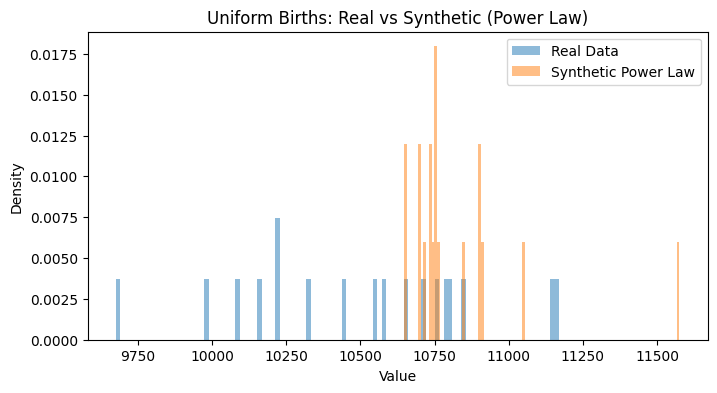

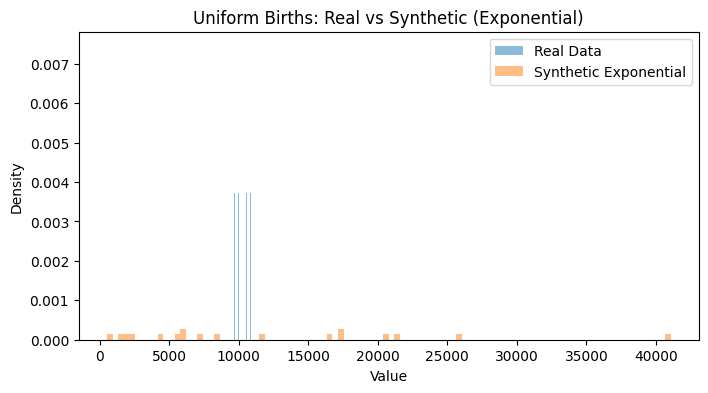

In [17]:
synthetic_uniform_norm = np.random.normal(mu_b, sigma_b, size=len(ohio_birth))
synthetic_uniform_uniform = np.random.uniform(a_b, b_b, size=len(ohio_birth))
r = np.random.uniform(0, 1, size=len(ohio_birth))
synthetic_uniform_power = xmin_b * (1 - r) ** (-1/(alpha_b - 1))
synthetic_uniform_exp = np.random.exponential(1/lambda_b, size=len(ohio_birth))

compare_distributions(ohio_birth, synthetic_uniform_norm, "Normal", "Uniform Births")
compare_distributions(ohio_birth, synthetic_uniform_uniform, "Uniform", "Uniform Births")
compare_distributions(ohio_birth, synthetic_uniform_power, "Power Law", "Uniform Births")
compare_distributions(ohio_birth, synthetic_uniform_exp, "Exponential", "Uniform Births")

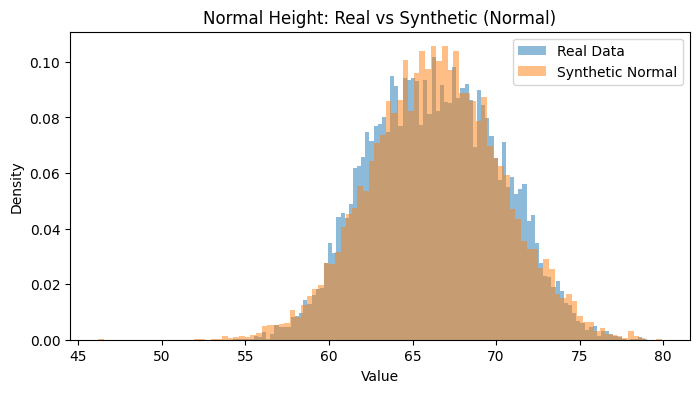

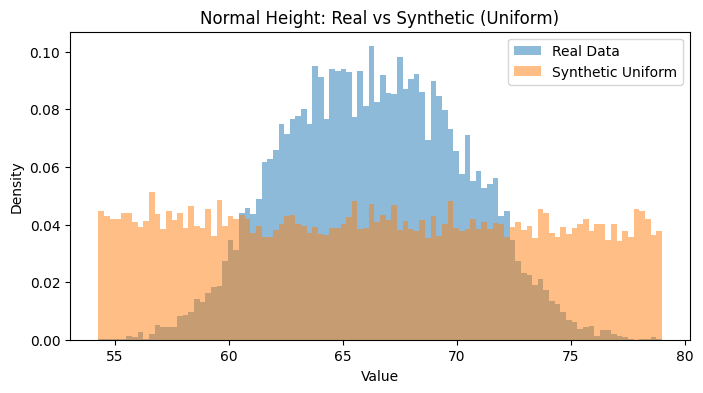

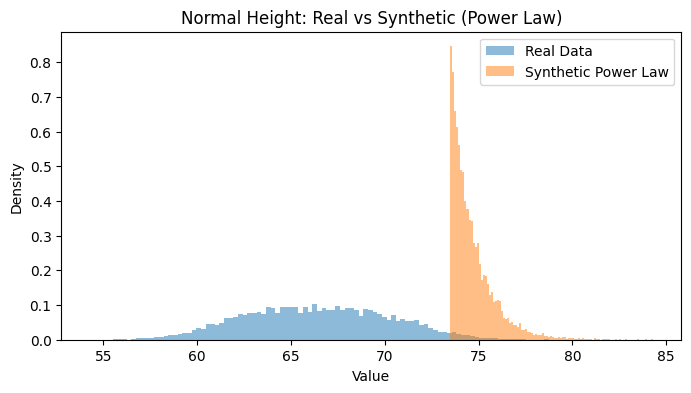

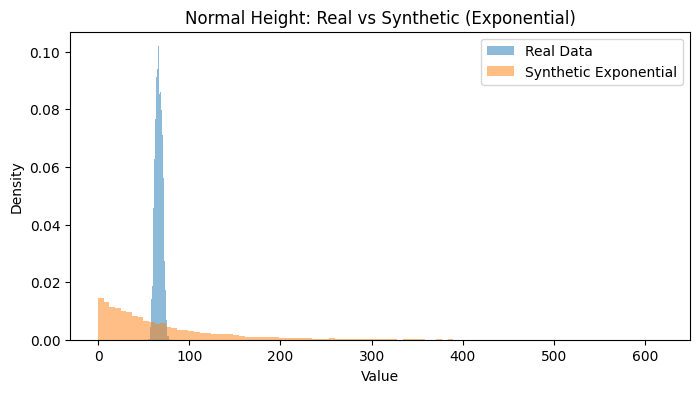

In [18]:
synthetic_norm_norm = np.random.normal(mu_h, sigma_h, size=len(height_df))
synthetic_norm_uniform = np.random.uniform(a_h, b_h, size=len(height_df))
r = np.random.uniform(0, 1, size=len(height_df))
synthetic_norm_power = xmin_h * (1 - r) ** (-1/(alpha_h - 1))
synthetic_norm_exp = np.random.exponential(1/lambda_h, size=len(height_df))

compare_distributions(height_df, synthetic_norm_norm, "Normal", "Normal Height")
compare_distributions(height_df, synthetic_norm_uniform, "Uniform", "Normal Height")
compare_distributions(height_df, synthetic_norm_power, "Power Law", "Normal Height")
compare_distributions(height_df, synthetic_norm_exp, "Exponential", "Normal Height")

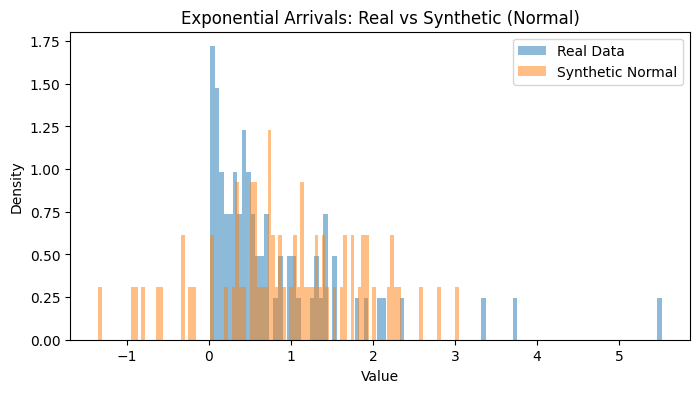

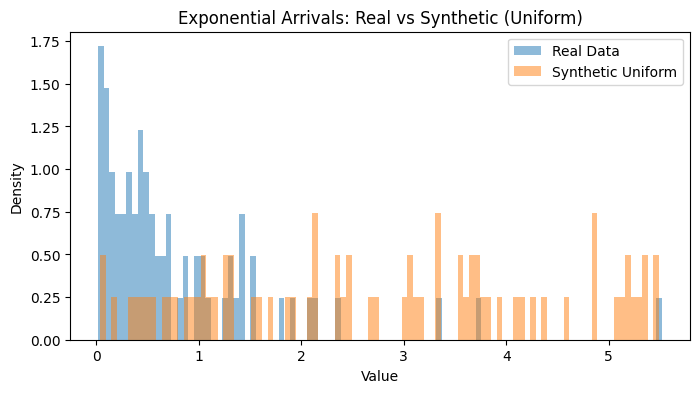

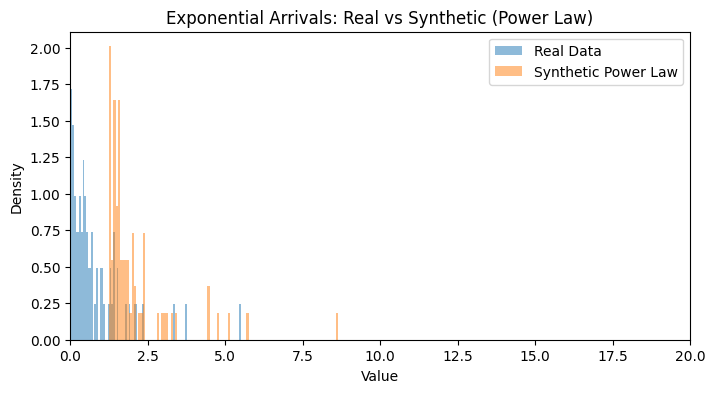

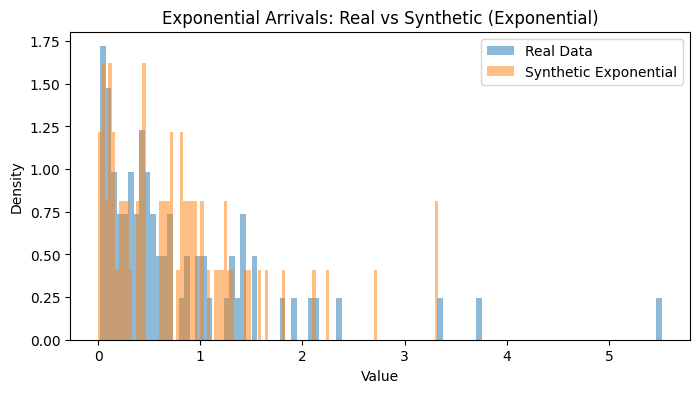

In [19]:
synthetic_exp_norm = np.random.normal(mu_ia, sigma_ia, size=len(interarrivals))
synthetic_exp_uniform = np.random.uniform(a_ia, b_ia, size=len(interarrivals))
r = np.random.uniform(0, 1, size=len(interarrivals))
synthetic_exp_power = xmin_ia * (1 - r) ** (-1/(alpha_ia - 1))
synthetic_exp_exp = np.random.exponential(1/lambda_ia, size=len(interarrivals))

compare_distributions(interarrivals, synthetic_exp_norm, "Normal", "Exponential Arrivals")
compare_distributions(interarrivals, synthetic_exp_uniform, "Uniform", "Exponential Arrivals")
compare_dist_misbehaved(interarrivals, synthetic_exp_power, "Power Law", "Exponential Arrivals", 20)
compare_distributions(interarrivals, synthetic_exp_exp, "Exponential", "Exponential Arrivals")

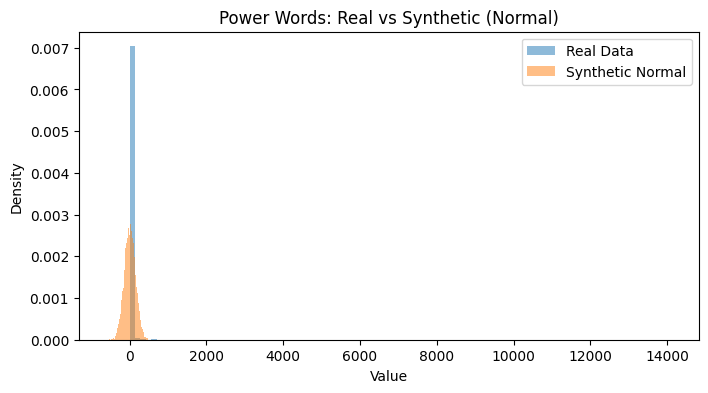

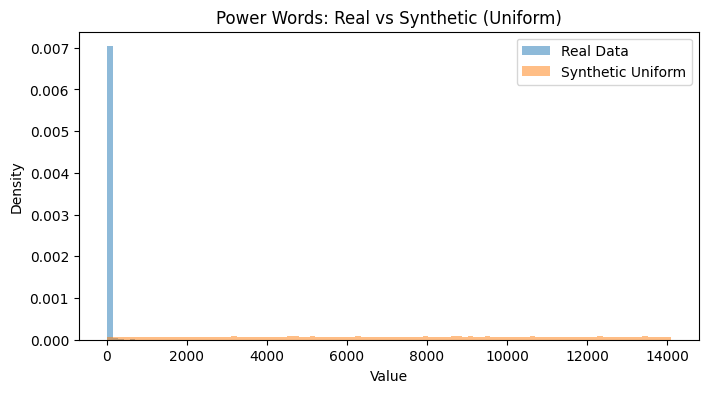

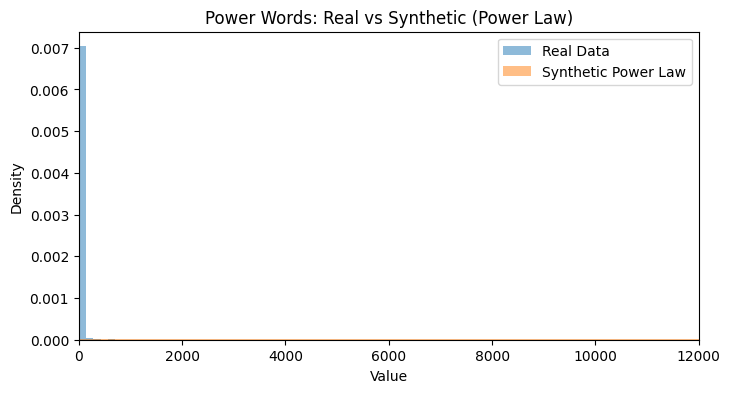

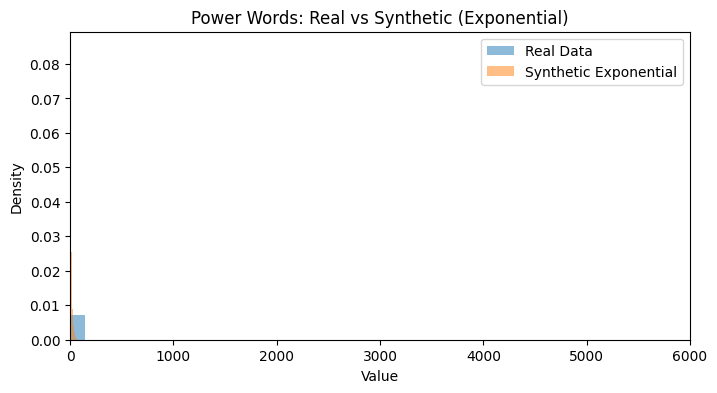

In [20]:
synthetic_exp_norm = np.random.normal(mu_MD, sigma_MD, size=len(moby_dick))
synthetic_exp_uniform = np.random.uniform(a_MD, b_MD, size=len(moby_dick))
r = np.random.uniform(0, 1, size=len(moby_dick))
synthetic_exp_power = xmin_MD * (1 - r) ** (-1/(alpha_MD - 1))
synthetic_exp_exp = np.random.exponential(1/lambda_MD, size=len(moby_dick))

compare_distributions(moby_dick, synthetic_exp_norm, "Normal", "Power Words")
compare_distributions(moby_dick, synthetic_exp_uniform, "Uniform", "Power Words")
compare_dist_misbehaved(moby_dick, synthetic_exp_power, "Power Law", "Power Words", 12000)
compare_dist_misbehaved(moby_dick, synthetic_exp_exp, "Exponential", "Power Words", 6000)